In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kepler-442b parameters
R_planet_earth = 1.34   # Earth radii
M_planet_earth = 2.3    # Earth masses
T_surface = 280         # K (assuming Earth-like atmosphere gets us above freezing)

# Physical constants
k_B = 1.38e-23          # Boltzmann constant
R_earth = 6.371e6       # metres
M_earth = 5.972e24      # kg
g_earth = 9.81          # m/s²

# Surface gravity scales as M/R²
g = g_earth * (M_planet_earth / R_planet_earth**2)

# Scale height for Earth-like atmosphere (mean molecular mass of air = 29 amu)
amu = 1.66e-27          # kg
m_air = 29 * amu

H = (k_B * T_surface) / (m_air * g)

print(f"Surface gravity: {g:.2f} m/s² (Earth = 9.81)")
print(f"Scale height: {H/1000:.1f} km (Earth = 8.5 km)")

Surface gravity: 12.57 m/s² (Earth = 9.81)
Scale height: 6.4 km (Earth = 8.5 km)


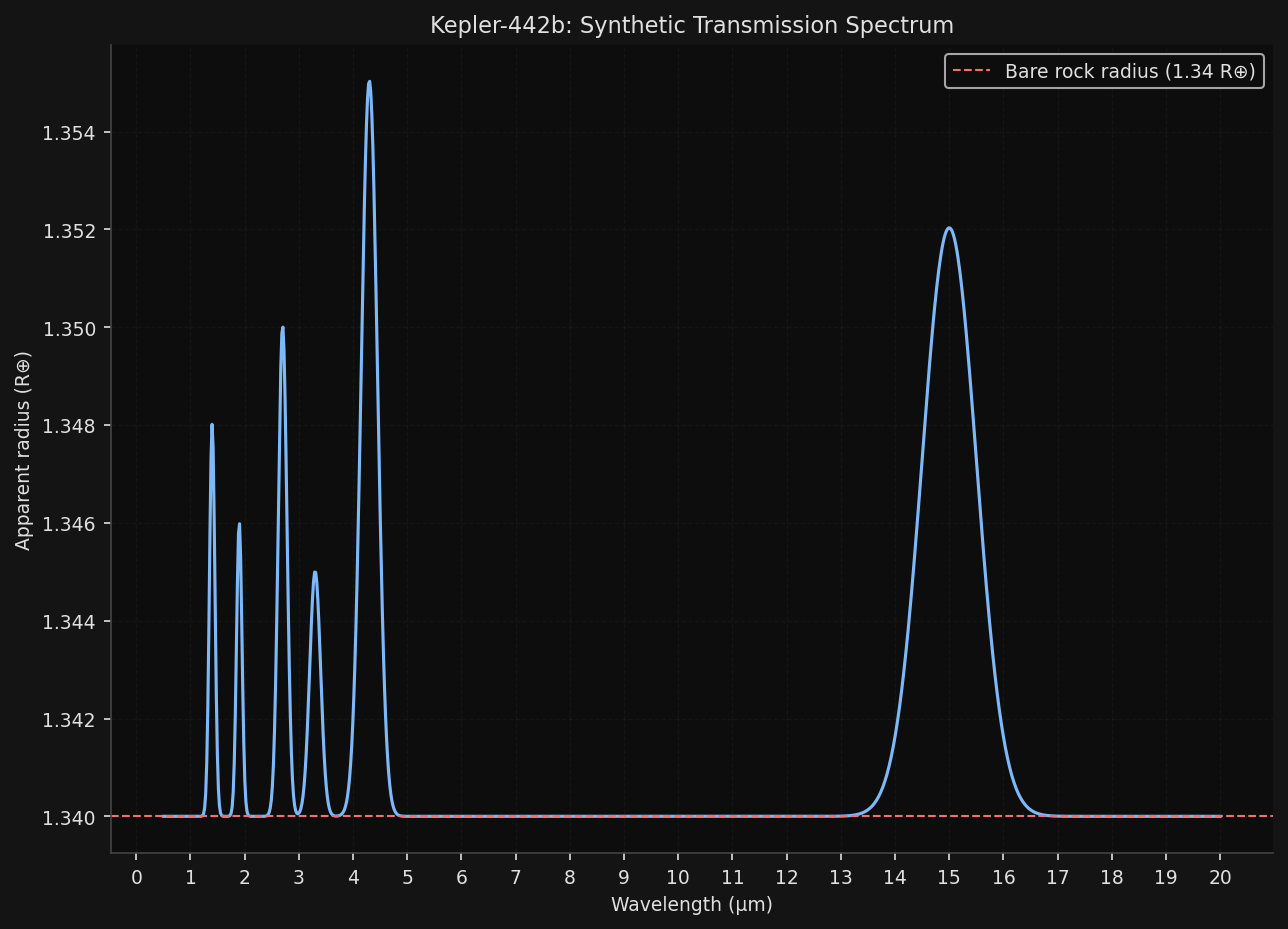

In [8]:
wavelength = np.linspace(0.5, 20, 1000)

R_baseline = R_planet_earth * R_earth

def absorption_bump(wavelength, center, width, strength):
    return H * strength * np.exp(-((wavelength - center)**2)/(2*width**2))

R_lambda = R_baseline * np.ones_like(wavelength)

# Water vapour
R_lambda += absorption_bump(wavelength, 1.4, 0.05, 8)
R_lambda += absorption_bump(wavelength, 1.9, 0.05, 6)
R_lambda += absorption_bump(wavelength, 2.7, 0.08, 10)

# CO2
R_lambda += absorption_bump(wavelength, 4.3, 0.15, 15)
R_lambda += absorption_bump(wavelength, 15.0, 0.5, 12)

# Methane
R_lambda += absorption_bump(wavelength, 3.3, 0.1, 5)

# Convert to Earth radii for plotting
R_lambda_earth = R_lambda / R_earth
plt.figure(figsize=(10, 7))
plt.plot(wavelength, R_lambda_earth, color='#7EB8F7', linewidth=1.5)
plt.axhline(y=R_planet_earth, color='#F76E6E', linestyle='--', 
            linewidth=1, label=f'Bare rock radius ({R_planet_earth} R⊕)')
plt.xlabel("Wavelength (μm)")
plt.xticks(np.arange(0, 21, 1))
plt.ylabel("Apparent radius (R⊕)")
plt.title("Kepler-442b: Synthetic Transmission Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
